In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
import lightgbm as lgb
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.impute import SimpleImputer
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


In [2]:
df=pd.read_csv(r"C:\Users\Lenovo\Desktop\Final Project\bank_credit_dataset.csv")
df.head()

,sk_id_curr,target,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,...,cc_amt_drawings_atm_current_sum,cc_amt_payment_current_mean,cc_amt_payment_total_current_mean,cc_amt_inst_min_regularity_mean,cc_sk_dpd_mean,cc_sk_dpd_max,cc_sk_dpd_def_mean,cc_sk_dpd_def_max,cc_cnt_drawings_current_sum,cc_cnt_instalment_mature_cum_mean
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Data Cleanning

In [3]:
null_ratio = df.isnull().mean()
null_ratio

sk_id_curr                           0.000000
target                               0.000000
name_contract_type                   0.000000
code_gender                          0.000000
flag_own_car                         0.000000
                                       ...   
cc_sk_dpd_max                        0.717392
cc_sk_dpd_def_mean                   0.717392
cc_sk_dpd_def_max                    0.717392
cc_cnt_drawings_current_sum          0.717392
cc_cnt_instalment_mature_cum_mean    0.717392
Length: 406, dtype: float64

we are finding null ratio for each column and comparing them with 0.7 ,if more that 70% of column is NaN ,we dont need them,they can affect model negatively

In [4]:
high_null_cols = null_ratio[null_ratio >0.7].index.tolist()
print(f'Number of cols that will be dropped: {len(high_null_cols)}')

df_clean = df.drop(columns=high_null_cols)

Number of cols that will be dropped: 16


df_clean

In [5]:
numeric_df =df.select_dtypes(include=[np.number]).fillna(0)
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

selector = VarianceThreshold(threshold=0.01)
selector.fit(numeric_df)

kept_cols = numeric_df.columns[selector.get_support()].tolist()
removed = [c for c in numeric_df.columns if c not in kept_cols]

print(f'Dropped columns: len{removed}')
print(f'Kept columns : {len(kept_cols)}')

df_var = df_clean.drop(columns=removed,errors='ignore')


Dropped columns: len['region_population_relative', 'apartments_avg', 'basementarea_avg', 'years_beginexpluatation_avg', 'years_build_avg', 'commonarea_avg', 'entrances_avg', 'floorsmin_avg', 'landarea_avg', 'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg', 'nonlivingarea_avg', 'apartments_mode', 'basementarea_mode', 'years_beginexpluatation_mode', 'years_build_mode', 'commonarea_mode', 'elevators_mode', 'entrances_mode', 'floorsmin_mode', 'landarea_mode', 'livingapartments_mode', 'livingarea_mode', 'nonlivingapartments_mode', 'nonlivingarea_mode', 'apartments_medi', 'basementarea_medi', 'years_beginexpluatation_medi', 'years_build_medi', 'commonarea_medi', 'elevators_medi', 'entrances_medi', 'floorsmin_medi', 'landarea_medi', 'livingapartments_medi', 'livingarea_medi', 'nonlivingapartments_medi', 'nonlivingarea_medi', 'totalarea_mode', 'amt_req_credit_bureau_hour', 'annuity_to_income', 'overdue_ratio__x', 'annuity_to_credit_ratio_x', 'applications_per_day_x', 'avg_pa

I used Variance Threshold method to filter and analyse columns due to threshold=0.01,if threshold< 0.01 ,it means we dont need that column

If we would use these columns instead of dropping them ,what would happen?:

    1. Model would work slowly than now
    
    2.Overfitting risk cuz of that kind of unuseful columns

Correlation filter

In [6]:
numeric_df = df_var.select_dtypes(include=[np.number])
string_df  = df_var.select_dtypes(exclude=[np.number])

corr_matrix = numeric_df.drop(columns=['target'], errors='ignore').corr().abs()

mask      = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_tri = corr_matrix.where(mask)

to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]

numeric_df_cleaned = numeric_df.drop(columns=to_drop)

print(f'Dropped numeric columns: {len(to_drop)}')
print(f'Kept numeric columns: {len(numeric_df_cleaned.columns)}')

Dropped numeric columns: 235
Kept numeric columns: 78


LightGBM ilə feature importance 

In [7]:
X = numeric_df_cleaned.drop(columns=['target', 'sk_id_curr', 'index'], errors='ignore')
y = df_var['target']


X = X.fillna(X.median())

model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X, y)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.333153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 13033
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


LGBMClassifier(class_weight='balanced', learning_rate=0.05, n_estimators=300,
               n_jobs=-1, random_state=42)

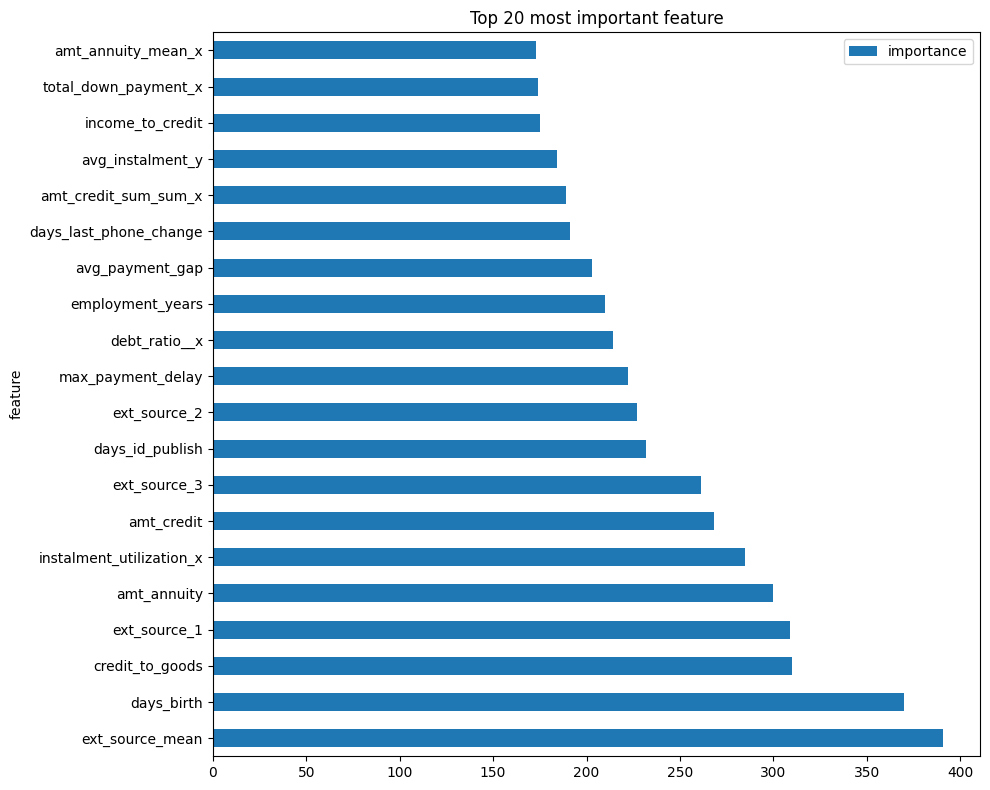

In [8]:
importance_df = pd.DataFrame({
    'feature'   : X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

top_60_numeric = importance_df.head(60)['feature'].tolist()

importance_df.head(20).plot(
    x='feature', y='importance', kind='barh', figsize=(10, 8)
)
plt.title('Top 20 most important feature')
plt.tight_layout()
plt.show()


In [9]:

cat_null_ratio = string_df.isnull().mean()
cat_keep = cat_null_ratio[cat_null_ratio <= 0.7].index.tolist()

df_final = pd.concat([
    numeric_df_cleaned[top_60_numeric], 
    string_df[cat_keep],             
    df_var[['target']]    
], axis=1)

In [10]:
df_final.info()
string_cols = df.select_dtypes(include=['object'])
string_cols

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 77 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   ext_source_mean               307511 non-null  float64
 1   days_birth                    307511 non-null  int64  
 2   credit_to_goods               307511 non-null  float64
 3   ext_source_1                  307511 non-null  float64
 4   amt_annuity                   307511 non-null  float64
 5   instalment_utilization_x      289444 non-null  float64
 6   amt_credit                    307511 non-null  float64
 7   ext_source_3                  307511 non-null  float64
 8   days_id_publish               307511 non-null  int64  
 9   ext_source_2                  307511 non-null  float64
 10  max_payment_delay             291635 non-null  float64
 11  debt_ratio__x                 262472 non-null  float64
 12  employment_years              307511 non-nul

,name_contract_type,code_gender,flag_own_car,flag_own_realty,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,weekday_appr_process_start,organization_type,fondkapremont_mode,housetype_mode,wallsmaterial_mode,emergencystate_mode
0,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,reg oper account,block of flats,"Stone, brick",No
1,Cash loans,F,N,N,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,reg oper account,block of flats,Block,No
2,Revolving loans,M,Y,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,NaN,NaN,NaN,NaN
3,Cash loans,F,N,Y,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,NaN,NaN,NaN,NaN
4,Cash loans,M,N,Y,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,Cash loans,M,N,N,Unaccompanied,Working,Secondary / secondary special,Separated,With parents,Sales staff,THURSDAY,Services,reg oper account,block of flats,"Stone, brick",No
307507,Cash loans,F,N,Y,Unaccompanied,Pensioner,Secondary / secondary special,Widow,House / apartment,NaN,MONDAY,XNA,reg oper account,block of flats,"Stone, brick",No
307508,Cash loans,F,N,Y,Unaccompanied,Working,Higher education,Separated,House / apartment,Managers,THURSDAY,School,reg oper account,block of flats,Panel,No
307509,Cash loans,F,N,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 1,NaN,block of flats,"Stone, brick",No


In [11]:
pd.set_option('display.max_rows',None)

In [12]:
for col in string_cols:
    print(f"\n{'='*50}")
    print(f"Sütun: {col}")
    print(f"Unikal sayı: {df_final[col].nunique()}")
    print(f"Null faizi: {df_final[col].isnull().mean():.2%}")
    print(f"Dəyərlər: {df_final[col].value_counts().head(5).to_dict()}")


Sütun: name_contract_type
Unikal sayı: 2
Null faizi: 0.00%
Dəyərlər: {'Cash loans': 278232, 'Revolving loans': 29279}

Sütun: code_gender
Unikal sayı: 3
Null faizi: 0.00%
Dəyərlər: {'F': 202448, 'M': 105059, 'XNA': 4}

Sütun: flag_own_car
Unikal sayı: 2
Null faizi: 0.00%
Dəyərlər: {'N': 202924, 'Y': 104587}

Sütun: flag_own_realty
Unikal sayı: 2
Null faizi: 0.00%
Dəyərlər: {'Y': 213312, 'N': 94199}

Sütun: name_type_suite
Unikal sayı: 7
Null faizi: 0.42%
Dəyərlər: {'Unaccompanied': 248526, 'Family': 40149, 'Spouse, partner': 11370, 'Children': 3267, 'Other_B': 1770}

Sütun: name_income_type
Unikal sayı: 8
Null faizi: 0.00%
Dəyərlər: {'Working': 158774, 'Commercial associate': 71617, 'Pensioner': 55362, 'State servant': 21703, 'Unemployed': 22}

Sütun: name_education_type
Unikal sayı: 5
Null faizi: 0.00%
Dəyərlər: {'Secondary / secondary special': 218391, 'Higher education': 74863, 'Incomplete higher': 10277, 'Lower secondary': 3816, 'Academic degree': 164}

Sütun: name_family_status
U

In [13]:
summary = []
for col in df_final.select_dtypes(include=['object']).columns:
    summary.append({
        'column'   : col,
        'nunique'  : df_final[col].nunique(),
        'null_pct' : f"{df_final[col].isnull().mean():.1%}",
        'top_vals' : list(df_final[col].value_counts().head(3).index)
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

                    column  nunique null_pct                                                             top_vals
        name_contract_type        2     0.0%                                        [Cash loans, Revolving loans]
               code_gender        3     0.0%                                                          [F, M, XNA]
              flag_own_car        2     0.0%                                                               [N, Y]
           flag_own_realty        2     0.0%                                                               [Y, N]
           name_type_suite        7     0.4%                             [Unaccompanied, Family, Spouse, partner]
          name_income_type        8     0.0%                           [Working, Commercial associate, Pensioner]
       name_education_type        5     0.0% [Secondary / secondary special, Higher education, Incomplete higher]
        name_family_status        6     0.0%                      [Married, Single / not

In [14]:
# dropping high percentage of NaN
high_null_cat = ['housetype_mode','wallsmaterial_mode',
                 'fondkapremont_mode','emergencystate_mode']
df_final=df_final.drop(columns=high_null_cat)


In [15]:
#There are XNA,we will make them NaN
df_final['code_gender']=df_final['code_gender'].replace('XNA',np.nan)

In [16]:
df_final['organization_type']=df_final['organization_type'].replace('XNA',np.nan)

In [17]:
df_final['age']=df_final['days_birth'] / -365
df_final.drop(columns='days_birth',inplace=True)
df_final.head()

,ext_source_mean,credit_to_goods,ext_source_1,amt_annuity,instalment_utilization_x,amt_credit,ext_source_3,days_id_publish,ext_source_2,max_payment_delay,...,name_type_suite,name_income_type,name_education_type,name_family_status,name_housing_type,occupation_type,weekday_appr_process_start,organization_type,target,age
0,0.161787,1.158394,0.083037,24700.5,0.600000,406597.5,0.139376,-2120,0.262949,-12.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,1,25.920548
1,0.466757,1.145198,0.311267,35698.5,0.520900,1293502.5,0.535276,-291,0.622246,-1.0,...,Family,State servant,Higher education,Married,House / apartment,Core staff,MONDAY,School,0,45.931507
2,0.642739,0.999993,0.505998,6750.0,0.473684,135000.0,0.729567,-2531,0.555912,-3.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Laborers,MONDAY,Government,0,52.180822
3,0.650442,1.052799,0.505998,29686.5,0.665385,312682.5,0.535276,-2437,0.650442,-1.0,...,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,Laborers,WEDNESDAY,Business Entity Type 3,0,52.068493
4,0.322738,0.999998,0.505998,21865.5,0.549165,513000.0,0.535276,-3458,0.322738,12.0,...,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,Core staff,THURSDAY,Religion,0,54.608219


In [18]:
df_final['age']=df_final['age'].astype(int)


In [19]:
df_final.to_pickle(r'C:\Users\Lenovo\Desktop\Home-Credit-Risk-Management\Datas\cleaned_data.pkl')

we can see that our target is inbalance (92% is Paid their credit ,and 8% is not paid their credit)